In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter
import re

# Initialize VADER
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df = pd.read_csv("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")
df['reviews.text'] = df['reviews.text'].fillna('')
df['reviews.title'] = df['reviews.title'].fillna('')

# 1. Analyze Title Sentiment vs. Body Sentiment
df['title_sentiment'] = df['reviews.title'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['body_sentiment'] = df['reviews.text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# 2. Calculate Discrepancy (Title vs Body)
df['sentiment_discrepancy'] = abs(df['title_sentiment'] - df['body_sentiment'])

# 3. Print Top 3 Discrepant Reviews
print("Top 3 Reviews with Title vs Body Discrepancies")
discrepant_samples = df.sort_values(by='sentiment_discrepancy', ascending=False).head(3)
for idx, row in discrepant_samples.iterrows():
    print(f"Title: {row['reviews.title']} (Score: {row['title_sentiment']})")
    print(f"Body: {row['reviews.text']} (Score: {row['body_sentiment']})")
    print("-" * 50)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


--- Top 3 Reviews with Title vs Body Discrepancies ---
Title: No Risk of Poor and Dangerous Knockoffs! (Score: -0.8687)
Body: It's true that these do not last as long as the big brands, especially in electronics (I opt for higher end batteries for things like my Mac mouse). BUT, the big brands are being knocked off all of the time. Even on this site, even with batteries purchased directly from Amazon, reviewers have found knockoffs.And knockoffs are not only a waste of money because they do not match the quality of the real brand, they can be dangerous. It is not unusual for knockoffs to lead acid into your equipment or device, and even to explode!So, I know that with AmazonBasics, I'm getting a safe and reputable brand.Perhaps if I were buying from a national bricks and mortar store, I would choose Duracell or Energizer. But on the web, AmazonBasics is the safe way to go. (Score: 0.9402)
--------------------------------------------------
Title: They still work, it's not like they come

In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download the official list of English stop words
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

stop_words.update(['amazon', 'product', 'device', 'buy', 'bought', 'get', 'got'])


all_words = " ".join(negative_reviews).lower().split()

# Clean
filtered_words = [word for word in all_words if word.isalpha() and word not in stop_words and len(word) > 2]

# Print the real, cleaned top 10
word_counts = Counter(filtered_words)
print("\n--- The REAL Top 10 Words in Negative Reviews ---")
print(word_counts.most_common(10))


--- The REAL Top 10 Words in Negative Reviews ---
[('batteries', 889), ('tablet', 294), ('battery', 277), ('last', 270), ('use', 256), ('fire', 256), ('one', 218), ('would', 214), ('kindle', 195), ('long', 176)]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...


Analyzing text sentiment...

--- Sentiment Breakdown ---
Sentiment
Positive    4510
Negative     270
Neutral      220
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_5408\2495005023.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', order=['Positive', 'Neutral', 'Negative'],


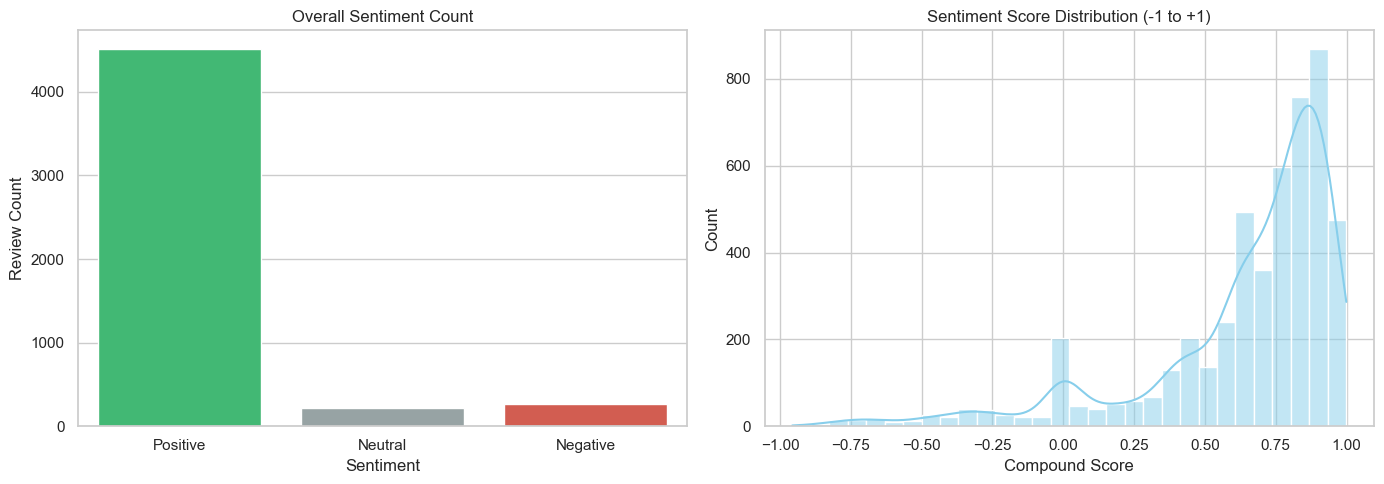

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon 
nltk.download('vader_lexicon')

# 1. Load the dataset 
df = pd.read_csv("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")

# 2. Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# 3. Calculate Sentiment Scores
print("Analyzing text sentiment...")
df['sentiment_score'] = df['reviews.text'].fillna('').apply(lambda x: sia.polarity_scores(x)['compound'])

# 4. Categorize scores into Positive, Neutral, and Negative
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['sentiment_score'].apply(categorize_sentiment)

# 5. Print a quick summary of the results
print("\n--- Sentiment Breakdown ---")
print(df['Sentiment'].value_counts())

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Sentiment Breakdown 
sns.countplot(data=df, x='Sentiment', order=['Positive', 'Neutral', 'Negative'], 
              palette={'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Overall Sentiment Count')
axes[0].set_ylabel('Review Count')

# Chart 2: Sentiment Score Distribution
sns.histplot(data=df, x='sentiment_score', bins=30, kde=True, color='skyblue', ax=axes[1])
axes[1].set_title('Sentiment Score Distribution (-1 to +1)')
axes[1].set_xlabel('Compound Score')

plt.tight_layout()
plt.show()